In [1]:
import pandas as pd
import numpy as np
import h5py
import re
import csv
import math
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_excel
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
#Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
# For Output
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

In [2]:
df_data = pd.read_csv('sevenk.csv')

In [3]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,negative
1,এটার সেকেন্ড পার্ট চাই দিদি। আজ শুধু রাবণের রো...,negative
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,negative
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,negative
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,positive
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,negative
21171,অসাধারন লেগেছে ভালো লেগেছে,negative
21172,স্যতি অসাধারণ,negative
21173,2014 তে এই ফিল্ম টি দেখছিলাম। অসাধারণ একটি মুভি।,negative


In [4]:
df_data['reaction_type'].value_counts()

reaction_type
negative    7116
positive    7065
neutral     6994
Name: count, dtype: int64

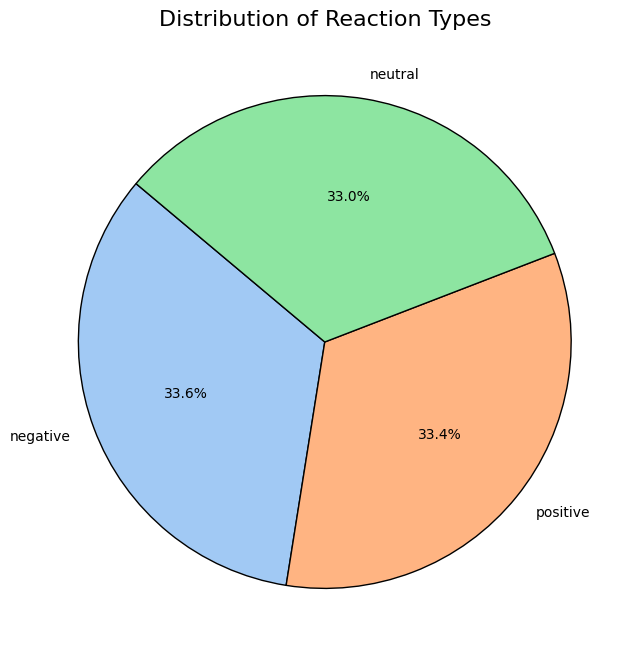

In [5]:
import seaborn as sns
reaction_counts = df_data['reaction_type'].value_counts()
colors = sns.color_palette("pastel")
plt.figure(figsize=(8, 8))
plt.pie(reaction_counts, labels=reaction_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title("Distribution of Reaction Types", fontsize=16)
plt.show()

In [6]:
def text_to_word_list(text):
    text = text.split()
    return text

def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations

                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    #latin_pattern=re.compile('[A-Za-z\u00C0-\u00D6\u00D8-\u00f6\u00f8-\u00ff\s]*',)

    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)

    return text

def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰🤣⚽️✌�￰৷￰'''

    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct = no_punct + char

    # display the unpunctuated string
    return no_punct

def joining(text):
    out=' '.join(text)
    return out

def preprocessing(text):
    out=remove_punctuations(replace_strings(text))
    return out

In [7]:
df_data['comments'] = df_data.comments.apply(lambda x: preprocessing(str(x)))

In [8]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,negative
1,এটার সেকেন্ড পার্ট চাই দিদি আজ শুধু রাবণের রোস...,negative
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,negative
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,negative
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,positive
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,negative
21171,অসাধারন লেগেছে ভালো লেগেছে,negative
21172,স্যতি অসাধারণ,negative
21173,তে এই ফিল্ম টি দেখছিলাম অসাধারণ একটি মুভি,negative


In [9]:
df_data["reaction_type"].replace({"negative": "0", "positive": "1","neutral": "2" }, inplace=True)

C:\Users\debbi\AppData\Local\Temp\ipykernel_3480\1620500157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_data["reaction_type"].replace({"negative": "0", "positive": "1","neutral": "2" }, inplace=True)


In [10]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,0
1,এটার সেকেন্ড পার্ট চাই দিদি আজ শুধু রাবণের রোস...,0
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,0
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,0
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,1
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,0
21171,অসাধারন লেগেছে ভালো লেগেছে,0
21172,স্যতি অসাধারণ,0
21173,তে এই ফিল্ম টি দেখছিলাম অসাধারণ একটি মুভি,0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(df_data['comments'], df_data['reaction_type'], test_size=0.2, random_state=42)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.decomposition import PCA

# 1. Data Preparation
X_train, X_test, y_train, y_test = train_test_split(df_data['comments'], df_data['reaction_type'], test_size=0.2, random_state=42)

# Tokenization and Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Label Encoding
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train)
y_test_bin = lb.transform(y_test)

from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_train_tensor = torch.tensor(np.argmax(y_train_bin, axis=1), dtype=torch.long)
y_test_tensor = torch.tensor(np.argmax(y_test_bin, axis=1), dtype=torch.long)

# Create DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Define GRU Model
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=2, dropout=0.5, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, hn = self.gru(x)
        x = self.dropout(hn[-1])
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Model parameters
vocab_size = 10000
embedding_dim = 128
hidden_dim = 64
epochs = 20
accumulation_steps = 4  # Number of steps to accumulate gradients

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss = loss / accumulation_steps  # Normalize loss to account for gradient accumulation
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

model.eval()
y_pred = []
y_test_single = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())
        y_test_single.extend(labels.numpy())

y_pred = np.array(y_pred)
y_test_single = np.array(y_test_single)
epochs = 20
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs, y_train_tensor.to(device))
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 4. Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor.to(device))
    y_pred = torch.argmax(outputs, axis=1).cpu().numpy()
    y_test_single = y_test_tensor.numpy()

# Metrics
accuracy = accuracy_score(y_test_single, y_pred) * 100
precision = precision_score(y_test_single, y_pred, average='weighted') * 100
recall = recall_score(y_test_single, y_pred, average='weighted') * 100
fscore = f1_score(y_test_single, y_pred, average='weighted') * 100

# Print with larger font-like effect and padding, all metrics in percentage
print("\n" + "="*50)
print("\n" + "Testing Accuracy:".center(25, " "), f"{accuracy:.2f}%".center(25, " "), "\n")
print("Precision :".center(25, " "), f"{precision:.2f}%".center(25, " "), "\n")
print("Recall :".center(25, " "), f"{recall:.2f}%".center(25, " "), "\n")
print("F1 Score :".center(25, " "), f"{fscore:.2f}%".center(25, " "), "\n")
print("="*50 + "\n")

# Confusion Matrix
cm = confusion_matrix(y_test_single, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with GRU')
plt.tight_layout()
plt.show()

# Generate classification report
report = pd.DataFrame(classification_report(y_test_single, y_pred, labels=[0, 1, 2], output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Print classification report with larger font-like effect and padding
print("\n" + "="*70)
print("Classification Report:".center(50, " "))
print("="*50)
print("\n" + " Class   ".center(15, " "), " Precision  ".center(15, " "), " Recall  ".center(15, " "), " F1-Score  ".center(15, " "))
print("="*50)

for index, row in report.iterrows():
    print(f"{index.center(15, ' ')} {row['precision']:>15} % {row['recall']:>10} % {row['f1-score']:>10} %")

print("="*70 + "\n")

# ROC Curve
n_classes = len(lb.classes_)
y_test_bin_binarized = label_binarize(y_test_single, classes=[0, 1, 2])
y_pred_prob = torch.softmax(outputs, dim=1).cpu().numpy()
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()

# 5. PCA Visualization (Before and After Training)
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

def plot_pca_side_by_side(before_embeddings, after_embeddings, labels):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title('PCA of GRU Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title('PCA of GRU Hidden States (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    initial_hidden_states = model.embedding(X_test_tensor.to(device))[:, -1, :].cpu().numpy()

model.eval()
with torch.no_grad():
    final_hidden_states = model.embedding(X_test_tensor.to(device))
    _, hn = model.gru(final_hidden_states)
    final_hidden_states = hn[-1].cpu().numpy()

plot_pca_side_by_side(initial_hidden_states, final_hidden_states, y_test_single)


Epoch [1/20], Loss: 145.9955
Epoch [2/20], Loss: 145.9733
Epoch [3/20], Loss: 145.9891
Epoch [4/20], Loss: 146.0081
Epoch [5/20], Loss: 145.9874
Epoch [6/20], Loss: 146.0097
Epoch [7/20], Loss: 146.0064
Epoch [8/20], Loss: 146.0252
Epoch [9/20], Loss: 146.0299
Epoch [10/20], Loss: 145.9123
Epoch [11/20], Loss: 146.0267
Epoch [12/20], Loss: 146.0285
Epoch [13/20], Loss: 145.9687
Epoch [14/20], Loss: 146.0396
Epoch [15/20], Loss: 146.1127
Epoch [16/20], Loss: 145.9309
Epoch [17/20], Loss: 145.9592
Epoch [18/20], Loss: 145.9405
Epoch [19/20], Loss: 146.0311
Epoch [20/20], Loss: 146.0197


OutOfMemoryError: CUDA out of memory. Tried to allocate 9.74 GiB. GPU 0 has a total capacity of 12.00 GiB of which 0 bytes is free. Of the allocated memory 8.57 GiB is allocated by PyTorch, and 8.50 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Epoch [1/20], Loss: 281.3257
Epoch [2/20], Loss: 260.4918
Epoch [3/20], Loss: 240.8190
Epoch [4/20], Loss: 222.1350
Epoch [5/20], Loss: 200.5084
Epoch [6/20], Loss: 182.5464
Epoch [7/20], Loss: 163.9827
Epoch [8/20], Loss: 149.4686
Epoch [9/20], Loss: 135.4156
Epoch [10/20], Loss: 125.4584
Epoch [11/20], Loss: 117.3262
Epoch [12/20], Loss: 109.5978
Epoch [13/20], Loss: 102.2255
Epoch [14/20], Loss: 95.6134
Epoch [15/20], Loss: 90.5117
Epoch [16/20], Loss: 87.6949
Epoch [17/20], Loss: 84.3759
Epoch [18/20], Loss: 79.4508
Epoch [19/20], Loss: 75.6851
Epoch [20/20], Loss: 74.8357


    Testing Accuracy:               58.47%          

       Precision :                  58.76%          

         Recall :                   58.47%          

        F1 Score :                  58.41%          




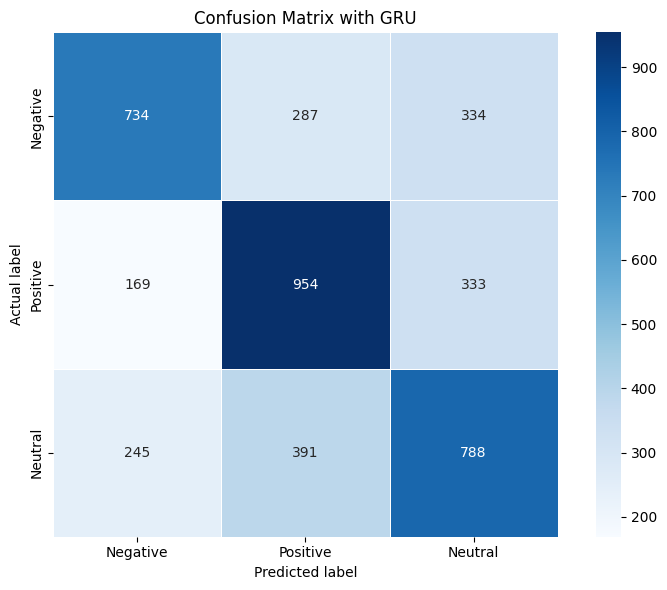


              Classification Report:              

    Class          Precision        Recall         F1-Score    
    Negative              63.94 %      54.17 %      58.65 %
    Positive              58.46 %      65.52 %      61.79 %
    Neutral               54.16 %      55.34 %      54.74 %
    accuracy              58.47 %      58.47 %      58.47 %
   macro avg              58.85 %      58.34 %      58.39 %
  weighted avg            58.76 %      58.47 %      58.41 %



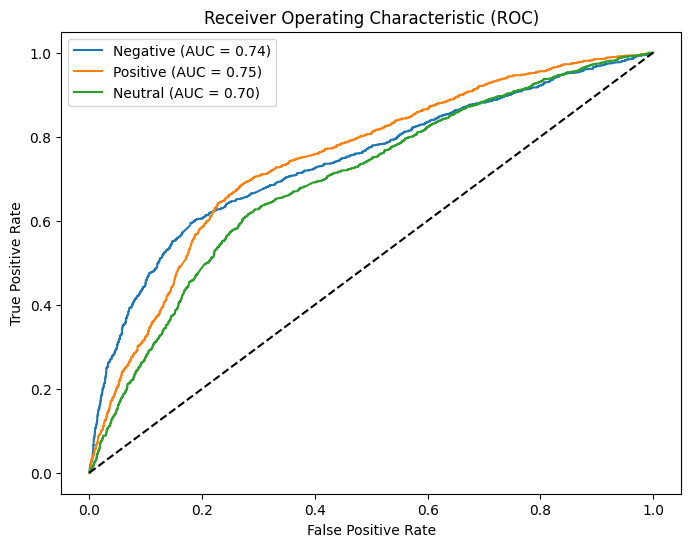

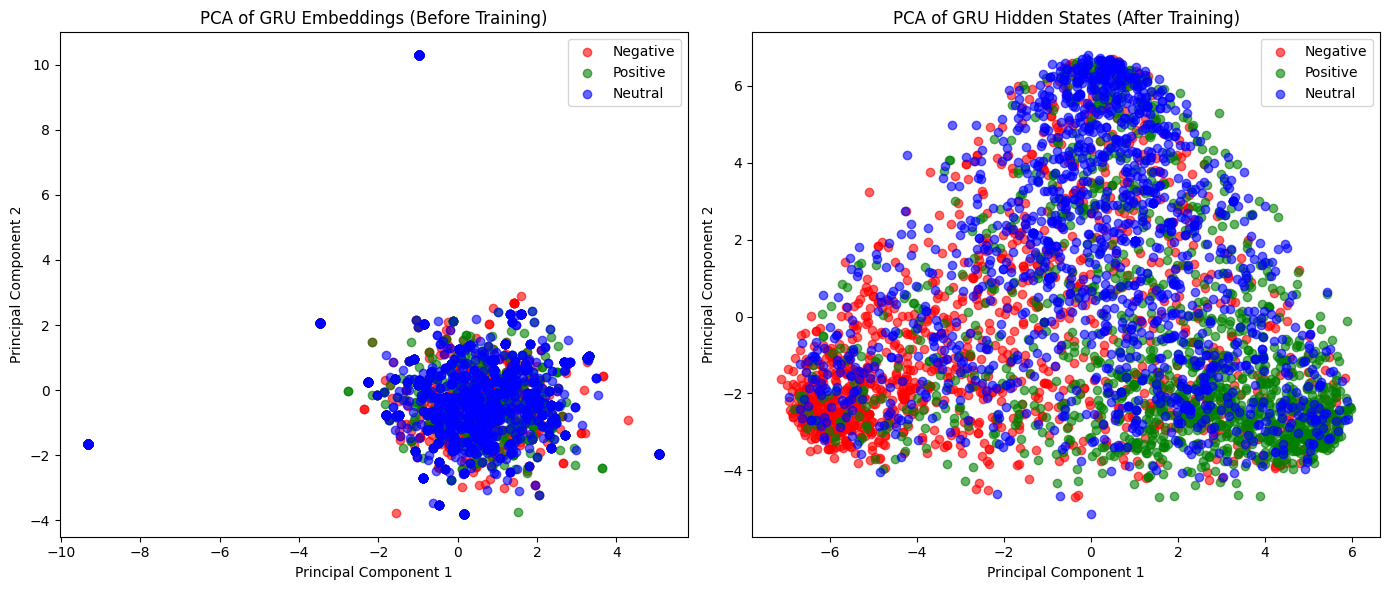

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.decomposition import PCA

# Clear GPU memory
torch.cuda.empty_cache()

# 1. Data Preparation
X_train, X_test, y_train, y_test = train_test_split(df_data['comments'], df_data['reaction_type'], test_size=0.2, random_state=42)

# Tokenization and Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Label Encoding
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train)
y_test_bin = lb.transform(y_test)

from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_train_tensor = torch.tensor(np.argmax(y_train_bin, axis=1), dtype=torch.long)
y_test_tensor = torch.tensor(np.argmax(y_test_bin, axis=1), dtype=torch.long)

# Create DataLoader
batch_size = 16  # Reduced batch size
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Define GRU Model
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=2, dropout=0.5, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, hn = self.gru(x)
        x = self.dropout(hn[-1])
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Model parameters
vocab_size = 10000
embedding_dim = 128
hidden_dim = 64
output_dim = 3
epochs = 20
accumulation_steps = 4  # Number of steps to accumulate gradients

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with gradient accumulation
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss = loss / accumulation_steps  # Normalize loss to account for gradient accumulation
        loss.backward()
        
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

# Evaluation
model.eval()
y_pred = []
y_test_single = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())
        y_test_single.extend(labels.numpy())

y_pred = np.array(y_pred)
y_test_single = np.array(y_test_single)

# Metrics
accuracy = accuracy_score(y_test_single, y_pred) * 100
precision = precision_score(y_test_single, y_pred, average='weighted') * 100
recall = recall_score(y_test_single, y_pred, average='weighted') * 100
fscore = f1_score(y_test_single, y_pred, average='weighted') * 100

# Print with larger font-like effect and padding, all metrics in percentage
print("\n" + "="*50)
print("\n" + "Testing Accuracy:".center(25, " "), f"{accuracy:.2f}%".center(25, " "), "\n")
print("Precision :".center(25, " "), f"{precision:.2f}%".center(25, " "), "\n")
print("Recall :".center(25, " "), f"{recall:.2f}%".center(25, " "), "\n")
print("F1 Score :".center(25, " "), f"{fscore:.2f}%".center(25, " "), "\n")
print("="*50 + "\n")

# Confusion Matrix
cm = confusion_matrix(y_test_single, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with GRU')
plt.tight_layout()
plt.show()

# Generate classification report
report = pd.DataFrame(classification_report(y_test_single, y_pred, labels=[0, 1, 2], output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Print classification report with larger font-like effect and padding
print("\n" + "="*70)
print("Classification Report:".center(50, " "))
print("="*50)
print("\n" + " Class   ".center(15, " "), " Precision  ".center(15, " "), " Recall  ".center(15, " "), " F1-Score  ".center(15, " "))
print("="*50)

for index, row in report.iterrows():
    print(f"{index.center(15, ' ')} {row['precision']:>15} % {row['recall']:>10} % {row['f1-score']:>10} %")

print("="*70 + "\n")

# ROC Curve
n_classes = len(lb.classes_)
y_test_bin_binarized = label_binarize(y_test_single, classes=[0, 1, 2])
y_pred_prob = []

model.eval()
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_pred_prob.extend(torch.softmax(outputs, dim=1).cpu().numpy())

y_pred_prob = np.array(y_pred_prob)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()

# 5. PCA Visualization (Before and After Training)
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

def plot_pca_side_by_side(before_embeddings, after_embeddings, labels):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title('PCA of GRU Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title('PCA of GRU Hidden States (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    initial_hidden_states = model.embedding(X_test_tensor.to(device))[:, -1, :].cpu().numpy()

model.eval()
with torch.no_grad():
    final_hidden_states = model.embedding(X_test_tensor.to(device))
    _, hn = model.gru(final_hidden_states)
    final_hidden_states = hn[-1].cpu().numpy()

plot_pca_side_by_side(initial_hidden_states, final_hidden_states, y_test_single)